In [10]:
%%html
<style>
    body {
        --vscode-font-family: "SeoulNamsanC", "Malgun Gothic", "Segoe UI Symbol", sans-serif;
    }
</style>

---
# **Chapter 5: Getting Started with pandas**
---

- pandas는 NumPy의 여러 코딩 방식을 따르지만, 가장 큰 차이점은 **pandas**가 **표 형식 데이터나 이질적인 데이터**를 다루도록 설계되었다는 점입니다. 반면 **NumPy**는 **동질적인 수치 배열 데이터**를 다루는 데 가장 적합합니다.

## **5.1 Introduction to pandas Data Structure**

### **Series**

In [ ]:
# 수치 연산을 위한 NumPy와 표 형식 데이터 처리를 위한 pandas를 불러옵니다.
# DataFrame과 Series는 pd 접두사 없이 사용할 수 있도록 별도로 import합니다.
import numpy as np
import pandas as pd
from pandas import DataFrame, Series
from IPython.display import display, Image

In [13]:
# list의 각 값에 d, b, a, c라는 index label을 지정하여 Series를 생성합니다.
# Series는 값과 index가 서로 연결된 1차원 자료구조입니다.
obj = pd.Series([4, 7, -5, 3], index=['d','b','a','c'])
obj

d    4
b    7
a   -5
c    3
dtype: int64

In [16]:
# Series obj에 저장된 값만 NumPy array 형태로 확인, index label만 Index 객체 형태로 확인
obj.values, obj.index

(array([ 4,  7, -5,  3]), Index(['d', 'b', 'a', 'c'], dtype='str'))

In [17]:
# obj2는 obj 복사본
# Series obj2에서 label이 'a'인 값을 선택합니다.
obj2 = obj.copy()
obj2['a']

np.int64(-5)

In [18]:
# obj2에서 label 'd'에 연결된 값을 6으로 변경한 뒤 전체 Series를 확인합니다.
obj2['d'] = 6
obj2

d    6
b    7
a   -5
c    3
dtype: int64

In [19]:
# 여러 label을 list로 전달하여 c, a, d 순서로 값을 선택합니다.
# 결과 Series의 순서는 원본 순서가 아니라 요청한 label 순서를 따릅니다.
obj2[['c', 'a', 'd']]

c    3
a   -5
d    6
dtype: int64

- 불리언 배열을 이용한 필터링, 스칼라 곱셈, 수학 함수 적용과 같은 NumPy 함수나 NumPy 방식의 연산을 수행해도 index와 값의 연결 관계는 유지됩니다:

In [20]:
# 불리언 조건 obj2 > 0을 이용해 값이 양수인 원소만 필터링합니다.
# 필터링 후에도 선택된 값과 기존 index label의 연결은 유지됩니다.
obj2[obj2>0]

d    6
b    7
c    3
dtype: int64

In [21]:
# obj2의 모든 값에 스칼라 2를 곱합니다. index는 바뀌지 않습니다.
obj2*2

d    12
b    14
a   -10
c     6
dtype: int64

In [22]:
# NumPy의 지수 함수 exp를 obj2의 각 값에 적용합니다.
# 결과도 기존 index를 유지하는 Series로 반환됩니다.
np.exp(obj2)

d     403.428793
b    1096.633158
a       0.006738
c      20.085537
dtype: float64

- Python dict에 담긴 데이터는 해당 dict를 전달하여 Series로 생성할 수 있습니다:

In [23]:
# 주 이름을 key, 인구를 value로 갖는 dict를 Series로 변환합니다.
# dict의 key는 Series의 index가 되고 value는 데이터가 됩니다.
sdata = {'Ohio':35000, 'Texas':71000, 'Oregon':16000, 'Utah':5000}
obj3 = pd.Series(sdata)
obj3

Ohio      35000
Texas     71000
Oregon    16000
Utah       5000
dtype: int64

In [24]:
# 별도의 states 순서를 index로 지정하여 sdata로부터 Series를 생성합니다.
# sdata에 없는 California에는 NaN이 들어가고, states에 없는 Utah는 결과에서 제외됩니다.
states = ['California', 'Ohio', 'Oregon', 'Texas']
obj4 = pd.Series(sdata, index=states)
obj4

California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
dtype: float64

- pandas에서 결측 데이터를 찾을 때는 ***isnull***과 ***notnull*** 함수를 사용합니다:
- Series에서도 이 함수들을 **instance method**로 사용할 수 있습니다:

In [25]:
# pd.isnull로 obj4의 각 값이 결측값인지 검사합니다.
# 같은 검사는 obj4.isnull() instance method로도 수행할 수 있습니다.
pd.isnull(obj4)                                                             #instance method : obj4.isnull()

California     True
Ohio          False
Oregon        False
Texas         False
dtype: bool

In [ ]:
# pd.notnull로 obj4의 각 값이 결측값이 아닌지 검사합니다.
# isnull의 반대인 불리언 Series를 반환합니다.
pd.notnull(obj4)                                                            #obj4.notnull()

California    False
Ohio           True
Oregon         True
Texas          True
dtype: bool

- **Series의 유용한 기능 중 하나는 산술 연산을 수행할 때 index label을 기준으로 데이터를 자동 정렬한다는 점입니다:**

In [33]:
# obj3와 obj4를 index label 기준으로 자동 정렬한 뒤 같은 label의 값을 더합니다.
# 어느 한쪽에만 존재하는 label은 대응값이 없으므로 결과가 NaN이 됩니다.
print(obj3)
print(obj4)
obj3 + obj4

Ohio      35000
Texas     71000
Oregon    16000
Utah       5000
dtype: int64
California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
dtype: float64


California         NaN
Ohio           70000.0
Oregon         32000.0
Texas         142000.0
Utah               NaN
dtype: float64

- Series 객체 자체와 그 index에는 모두 name attribute가 있으며, 이는 pandas의 다른 주요 기능과 연계되어 사용됩니다:

In [34]:
# Series 자체의 이름은 population, index 축의 이름은 state로 지정합니다.
# 이 이름은 출력이나 다른 pandas 자료구조와 결합할 때 metadata로 활용됩니다.
obj4.name = 'population'
obj4.index.name = 'state'
obj4

state
California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
Name: population, dtype: float64

In [35]:
# 새로운 label list를 할당하여 obj의 index를 직접 교체합니다.
# 값은 그대로 유지되고 각 값에 연결된 label만 같은 위치의 새 label로 바뀝니다.
obj.index = ['Bob', 'Steve', 'Jeff', 'Ryan']
obj

Bob      4
Steve    7
Jeff    -5
Ryan     3
dtype: int64

### **DataFrame**

- DataFrame을 생성하는 방법은 다양하지만, 가장 일반적인 방법 중 하나는 **길이가 같은 list 또는 NumPy array로 구성된 dict**를 사용하는 것입니다:

In [36]:
# 길이가 같은 list들로 구성된 dict를 이용해 DataFrame을 생성합니다.
# dict의 key는 column name이 되고, 별도 index가 없으므로 정수 index가 자동 생성됩니다.
data = {'state': ['Ohio', 'Ohio', 'Ohio', 'Nevada', 'Nevada', 'Nevada'],
       'year': [2000, 2001, 2002, 2001, 2002, 2003],
       'pop': [1.5, 1.7, 3.6, 2.4, 2.9, 3.2]}
frame = pd.DataFrame(data)
frame

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


- column의 순서를 지정하면 DataFrame의 column이 지정한 순서대로 배치됩니다:

In [37]:
# column 순서와 row index를 명시하여 data로부터 새로운 DataFrame을 생성합니다.
# data에 없는 debt column은 값이 없으므로 모두 NaN으로 채워집니다.
frame2 = pd.DataFrame(data, columns=['year', 'state', 'pop', 'debt'],
                     index=['one', 'two', 'three', 'four', 'five', 'six'])
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,NaN
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,NaN
five,2002,Nevada,2.9,NaN
six,2003,Nevada,3.2,NaN


- DataFrame의 column은 dict 방식의 표기법이나 attribute를 사용하여 Series로 가져올 수 있습니다:
- 편의를 위해 attribute 방식의 접근(예: frame2.year)과 IPython에서의 column name tab completion이 제공됩니다. 
- frame2[column]은 어떤 column name에도 사용할 수 있지만, **frame2.column**은 column name이 유효한 Python variable name일 때만 사용할 수 있습니다.

In [38]:
# dict 방식으로 state column을 선택합니다. 결과는 frame2와 같은 index를 가진 Series입니다.
frame2['state']                                                             #frame2.state

one        Ohio
two        Ohio
three      Ohio
four     Nevada
five     Nevada
six      Nevada
Name: state, dtype: str

In [39]:
# attribute 방식으로 year column을 선택합니다. frame2['year']와 같은 결과입니다.
# column name이 유효한 Python variable name일 때만 이 방식을 사용할 수 있습니다.
frame2.year                                                                 #frame2['year']

one      2000
two      2001
three    2002
four     2001
five     2002
six      2003
Name: year, dtype: int64

- 반환된 Series는 DataFrame과 동일한 index를 가지며, ***name*** attribute도 알맞게 설정됩니다.
- column에 **list 또는 array를 할당**할 때는 값의 길이가 **DataFrame의 길이와 일치**해야 합니다. **Series를 할당**하면 Series의 **label이 DataFrame의 index에 맞게 정확히 재정렬**되며, 값이 없는 위치에는 결측값이 삽입됩니다:

In [40]:
# 0부터 5까지의 NumPy array를 debt column에 순서대로 할당합니다.
# array를 할당할 때는 값의 길이가 DataFrame의 row 수와 같아야 합니다.
frame2['debt'] = np.arange(6)                                               #Column 이름 접근
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,0
two,2001,Ohio,1.7,1
three,2002,Ohio,3.6,2
four,2001,Nevada,2.4,3
five,2002,Nevada,2.9,4
six,2003,Nevada,3.2,5


In [ ]:
# 일부 row label만 가진 Series를 debt column에 할당합니다.
# pandas가 index label을 기준으로 값을 정렬하며, 대응 label이 없는 row에는 NaN을 넣습니다.
val = pd.Series([-1.2, -1.5, -1.7], index=['two', 'four', 'five'])
frame2.debt = val                                                           #Attribute 접근
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,-1.2
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,-1.5
five,2002,Nevada,2.9,-1.7
six,2003,Nevada,3.2,NaN


- **DataFrame을 indexing하여 반환된 column은 원본 데이터의 copy가 아니라 view입니다**. 
- 따라서 Series를 in-place 방식으로 수정하면 그 변경 사항이 DataFrame에도 반영됩니다. 
Series의 ***copy*** method를 사용하면 column을 명시적으로 복사할 수 있습니다.

- 중첩된 dict를 DataFrame에 전달하면 pandas는 **바깥쪽 dict의 key를 column**으로, **안쪽 dict의 key를 row index**로 해석합니다:

In [42]:
# 바깥쪽 key가 주 이름이고 안쪽 key가 연도인 중첩 dict를 생성합니다.
# 이후 DataFrame으로 변환하면 바깥쪽 key는 column, 안쪽 key는 row index가 됩니다.
pop = {'Nevada': {2001:2.4, 2002:2.9},
      'Ohio': {2000:1.5, 2001:1.7, 2002:3.6}}

In [43]:
# 중첩 dict pop을 연도 index가 2000~2002인 DataFrame으로 변환합니다.
# Nevada의 2000년 값처럼 원본 dict에 없는 조합은 NaN으로 채워집니다.
frame3 = pd.DataFrame(pop, index=[2000, 2001, 2002])
frame3

,Nevada,Ohio
2000,NaN,1.5
2001,2.4,1.7
2002,2.9,3.6


In [44]:
# frame3를 전치하여 row와 column을 서로 바꿉니다.
frame3.T

,2000,2001,2002
Nevada,NaN,2.4,2.9
Ohio,1.5,1.7,3.6


In [45]:
# Series들로 구성된 dict 역시 중첩 dict와 비슷한 방식으로 DataFrame으로 변환됩니다.
# 서로 다른 범위로 잘라낸 Series들이 index label에 맞춰 정렬되며 빈 위치에는 NaN이 들어갑니다.
pdata = {'Ohio': frame3['Ohio'][:-1],
        'Nevada': frame3['Nevada'][:2]}
pd.DataFrame(pdata, columns = ['Nevada', 'Ohio' ])

,Nevada,Ohio
2000,NaN,1.5
2001,2.4,1.7


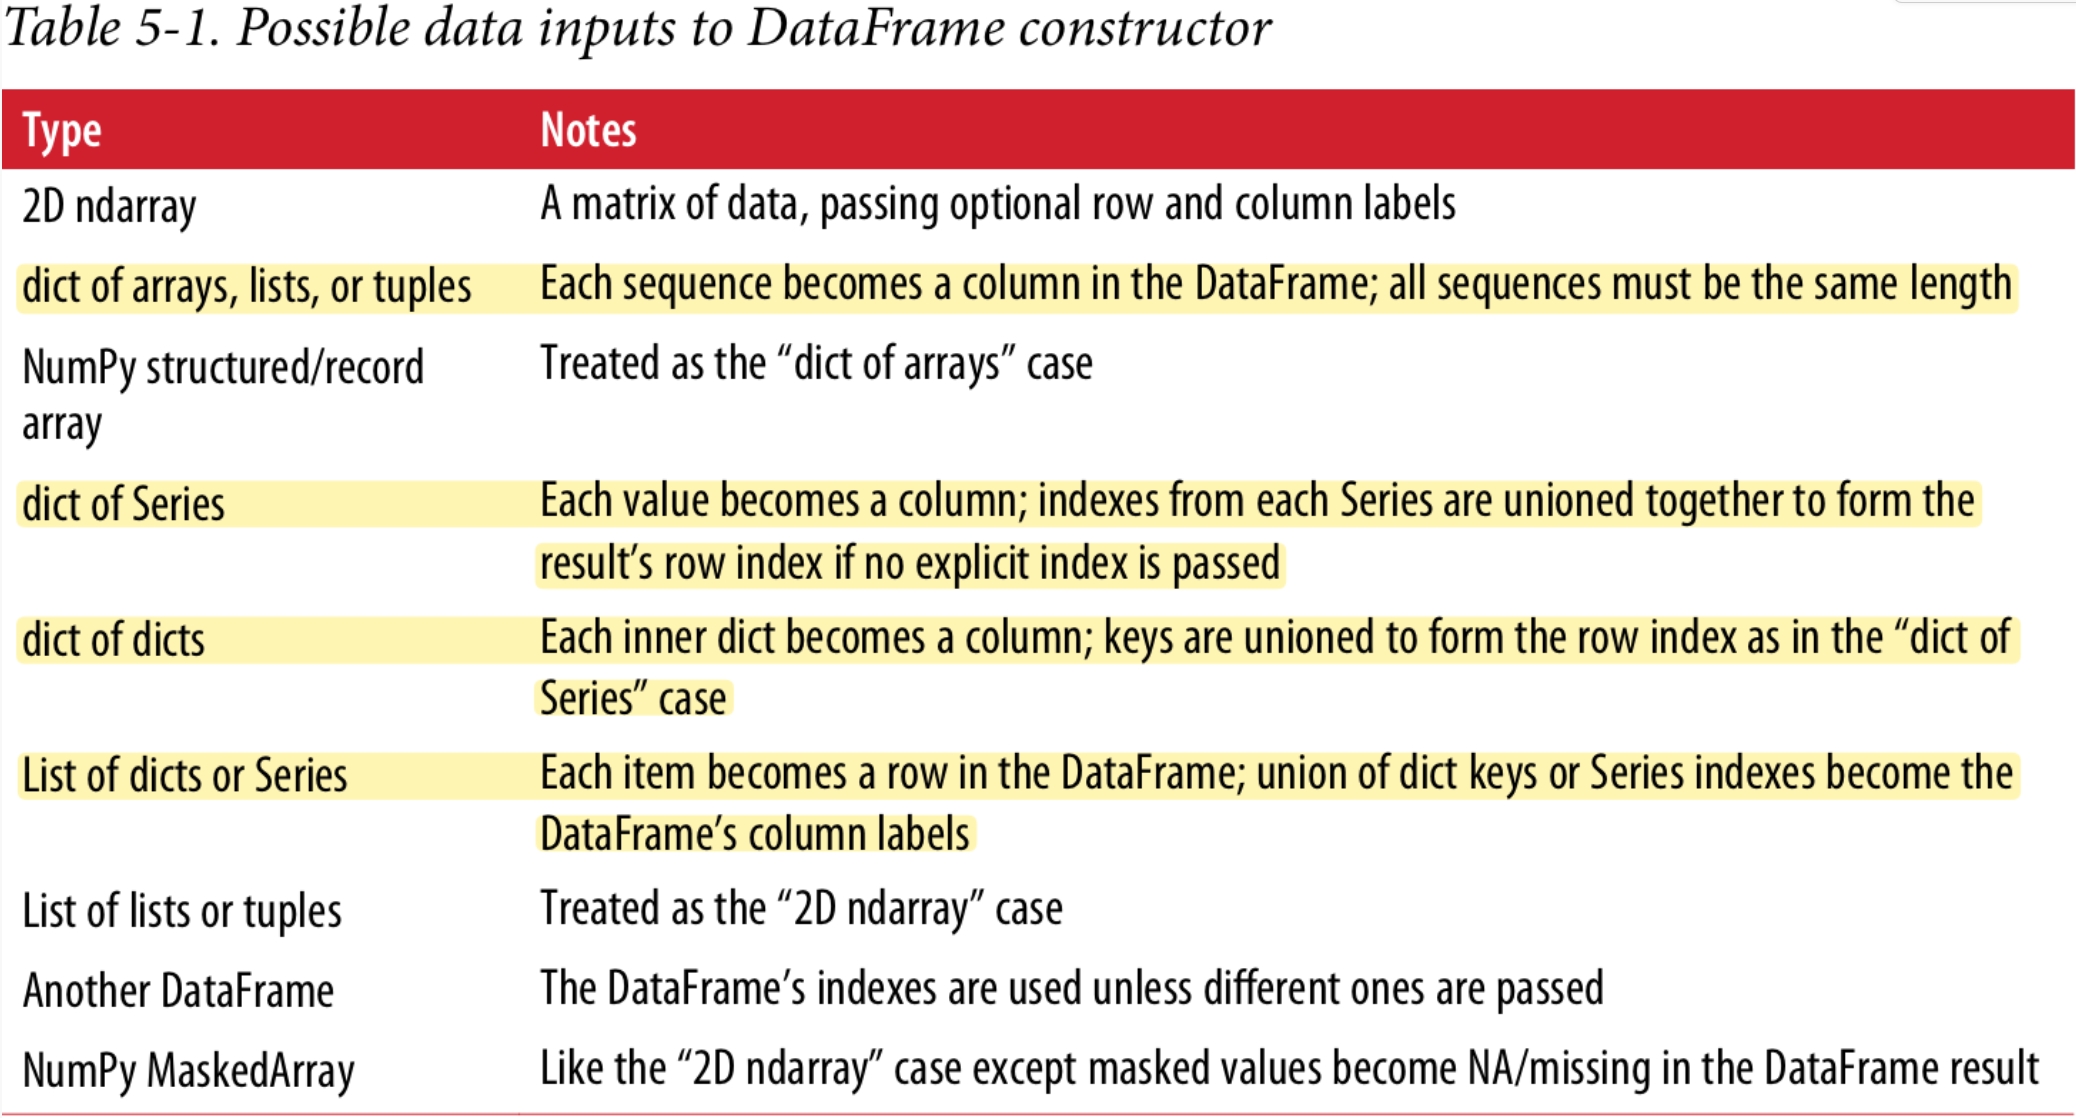

In [ ]:
display(Image(filename='../Images/Table5-1.png', width=800))

### **Index Objects**

- Index 객체는 **immutable**이므로 사용자가 직접 수정할 수 없습니다.
- Index는 **크기가 고정된 set**처럼 동작하기도 합니다.
- Python set과 달리 pandas Index에는 **중복된 label이 포함될 수 있습니다**.

In [54]:
# 이후 Index 객체의 속성을 살펴보기 위해 현재 frame3를 다시 확인합니다.
frame3

state,Nevada,Ohio
2000,NaN,1.5
2001,2.4,1.7
2002,2.9,3.6


In [55]:
# frame3의 column 축 이름을 state로 지정한 뒤 columns Index를 확인합니다.
# column label 자체가 아니라 column 축을 설명하는 name metadata를 설정하는 연산입니다.
frame3.columns.name = 'state'
frame3.columns

Index(['Nevada', 'Ohio'], dtype='str', name='state')

In [56]:
# 'Ohio' label이 frame3의 columns Index에 포함되어 있는지 검사합니다.
'Ohio' in frame3.columns

True

In [57]:
# 2003 label이 frame3의 row index에 포함되어 있는지 검사합니다.
# DataFrame의 row index에는 소문자인 index attribute로 접근합니다.
2003 in frame3.index # Attribute 접근시 index 소문자 사용

False

In [58]:
# pd.Index 생성자를 사용해 중복 label을 포함하는 Index 객체를 만듭니다.
# Index는 immutable이지만 label의 중복 자체는 허용됩니다.
dup_labels = pd.Index(['foo', 'foo', 'bar', 'bar'])
dup_labels

Index(['foo', 'foo', 'bar', 'bar'], dtype='str')

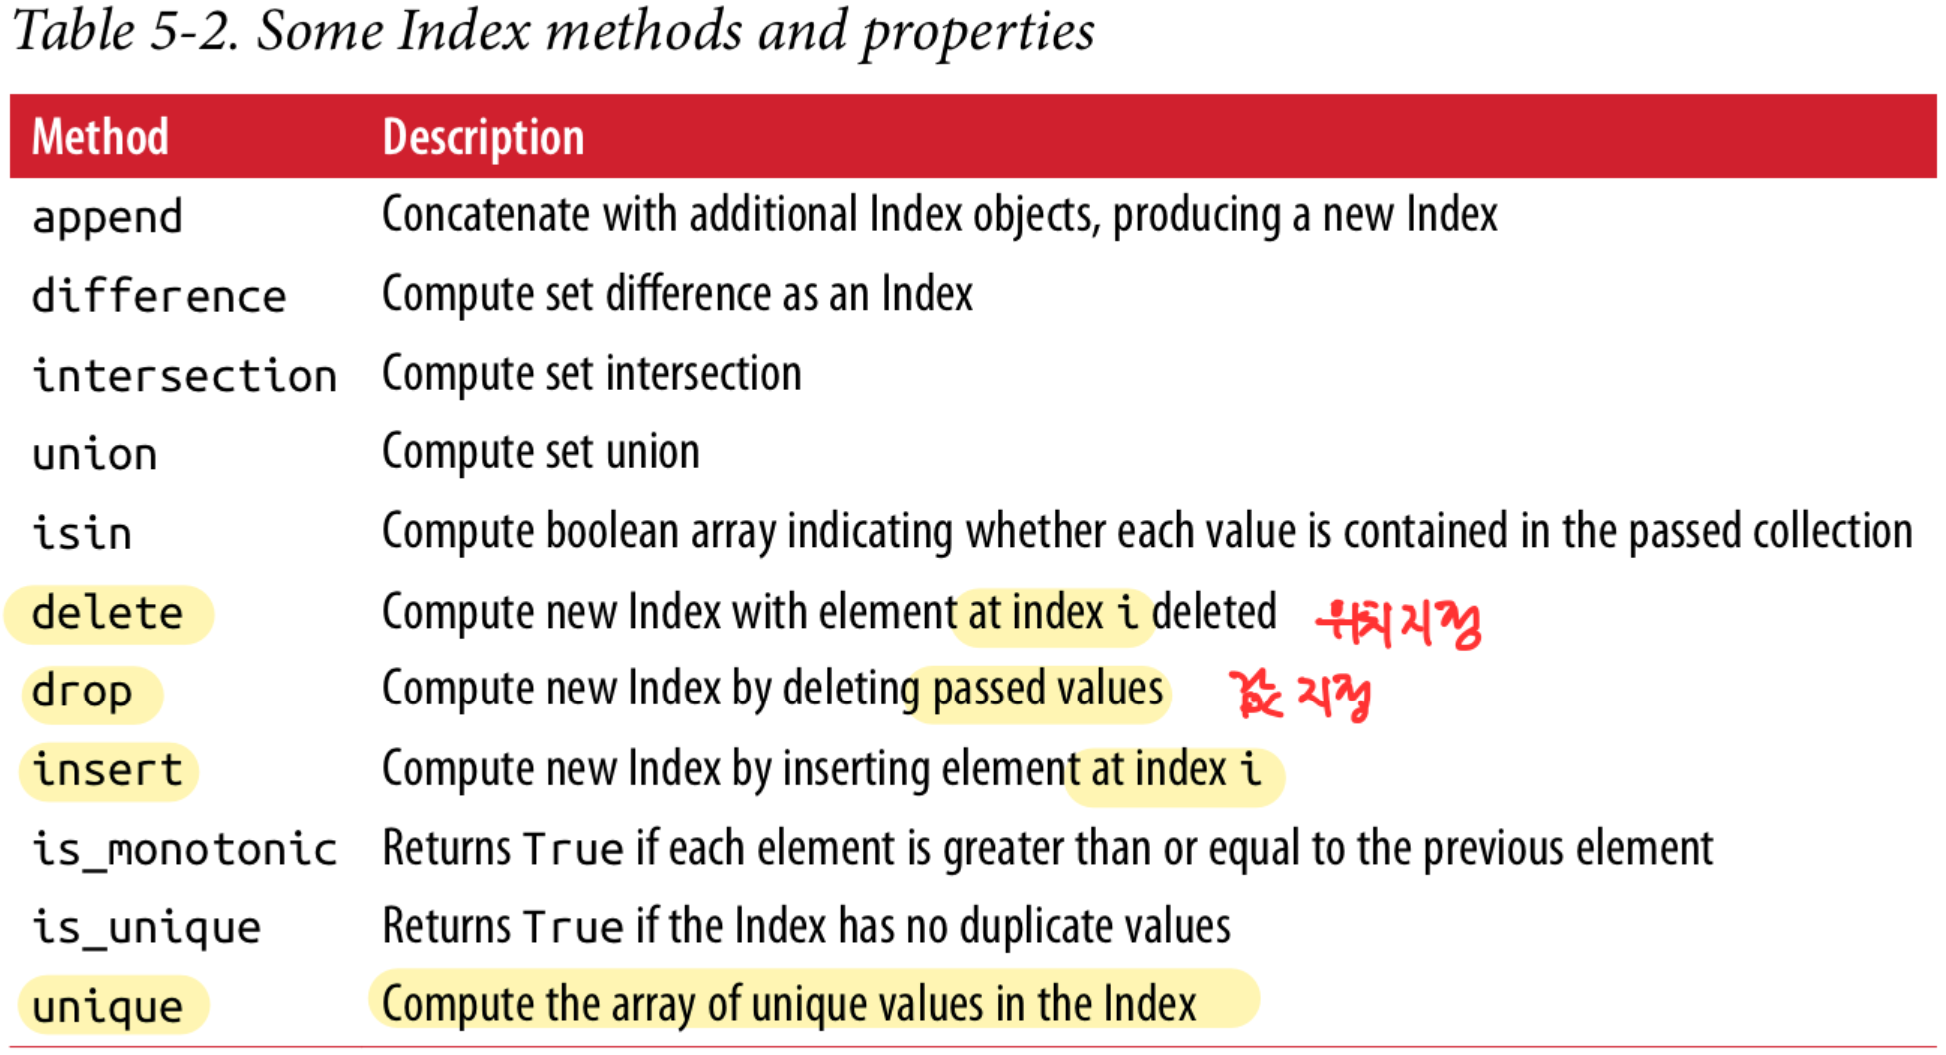

In [59]:
display(Image(filename='../Images/Table5-2.png', width=800))

In [60]:
# frame3.index 뒤에 label 20을 붙인 새로운 Index 객체를 반환합니다.
# append는 기존 frame3.index를 직접 변경하지 않으므로 결과를 사용하려면 별도로 저장해야 합니다.
frame3.index.append(pd.Index([20]))

Index([2000, 2001, 2002, 20], dtype='int64')

In [ ]:
# 추가 pandas Series, DataFrame 또는 Index 연산을 자유롭게 실습하기 위한 빈 셀입니다.